# {docnum}`step ref` Monte Carlo Uncertainty Propagation

Sometimes a measurand is determined by combining other measurements, but the combined standard uncertainty cannot be determined directly.
One approach to determining a combined standard uncertainty for this is to use a Monte Carlo approach, as outlined in 
_Supplement 1 to the GUM - Propagation of distributions using a Monte Carlo method_
{cite}`u-mc-JCGM101`.
<!-- _Evaluation of measurement data - Supplement 1 to the GUM - Propagation of distributions using a Monte Carlo method_ -->

Consider a measurand $Y$ obtained by combining measurands $X_i$ for $i= 1, \dots, X_N$ through the relation:

$$
Y = f(X_1, \dots, X_N)
$$

The goal of our Monte Carlo method (MCM) is to approximate the PDF of Y, which it will achieve through repeated sampling of the PDFs for the $X_i$.
Let's take $M$ samples of each of the PDFs for $X_i$, which gives us the values $x_{i,~r}$ for $r = 1, \dots, M$.
From these we can determine the corresponding $y_r$ values:

$$
y_r = f(x_{1,~r}, \dots, x_{N,~r})
$$

These $y_r$ values can be used to approximate the PDF of $Y$.
From this PDF we can determine the best approximation $y$ as the expected value and the standard uncertainty $u(y)$ as the standard deviation.
If the $y_r$ appear to be normally distributed (after using a histogram of the $y_r$ to convince ourselves),
then the best approximation can be determined using the arithmetic mean:

$$
y = \bar{y} = \frac{1}{M} \sum_{r=1}^M y_r
$$

and the standard uncertainty from the experimental standard deviation:

$$
u(y) = s(\bar{y}) = \frac{1}{M-1} \sum_{r=1}^M (y_r - \bar{y})^2
$$

## Sampling Random Numbers From PDFs

To sample random values for $X_i$, we need to know the PDF that defines its dispersion.
This PDF can often be re-constructed given a best approximation ($x_i$), standard uncertainty ($u(x_i)$) and knowledge of what kind of distribution defines the dispersion (e.g. normal, uniform, triangular); at least this will be the case for the problems covered in this course.

To generate a sample of random numbers from a PDF we can use random number generators from NumPy. You can find a list of distributions [here](https://numpy.org/doc/stable/reference/random/generator.html#distributions), though the distributions that we are most interested in are:

- Normal distribution: [`normal`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html) (commonly resulting from a Type A uncertainty evaluation)
- Uniform distribution: [`uniform`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.uniform.html) (commonly resulting from a Type B uncertainty evaluation)
- Triangular distribution [`triangle`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.triangular.html) (commonly resulting from a Type B uncertainty evaluation)

:::{note}
Here we are using the more up-to-date random number generators from the [Generator](https://numpy.org/doc/stable/reference/random/generator.html) class.
For the purpose of this course you may use the legacy random number generators which still appear in earlier parts of the notes,
though you are advised to use the new generators for new code.
:::


<div class="worked-example">
    <p class="worked-example-title">Worked Example - Generating <math><msub> <mi>x</mi> <mrow> <mi>i</mi> <mo>,</mo> <mi>r</mi> </mrow> </msub></math></p>

In this worked example we will focus on generating random samples for input variables $X_i$, this is **not** a full solution for the Monte Carlo method.

Consider 3 quantities with same best approximation and standard uncertainty:

$$
x_0 = x_1 = x_2 = 10 \quad \text{and} \quad u(x_0) = u(x_1) = u(x_2) = 1
$$

but with different PDFs characterizing their dispersion:

- $X_0$ with a normal distribution
- $X_1$ with a uniform distribution
- $X_2$ with a triangle distribution

We will use $M = 10000$ samples for the random $x_{i,~r}$ samples and plot histograms of these.

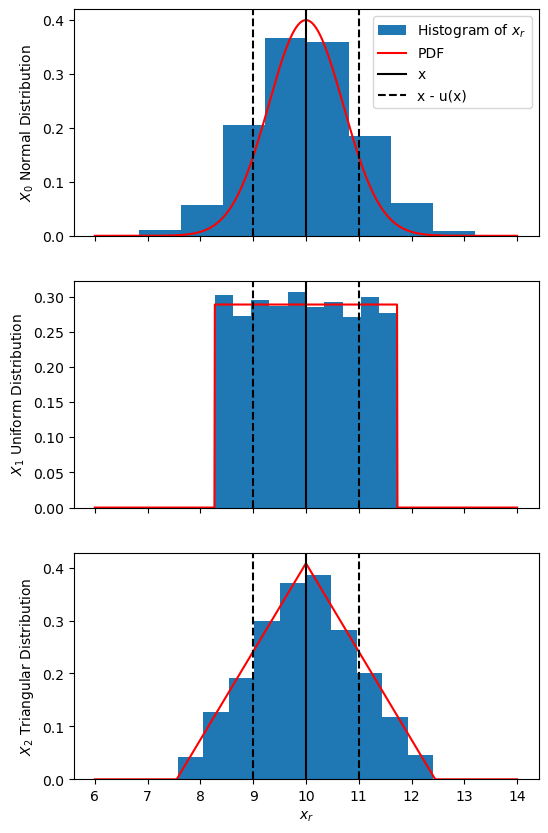

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()

x = 10
u_x = 1
M = 10000

#x-values for plotting distributions
x_plot = np.linspace(6, 14, 1000)

# Functional forms of the PDFs (used for plotting)
def norm_dist(x, mean, sigma):
    return np.exp( -(x - mean) ** 2 / sigma / sigma ) / sigma / np.sqrt(2 * np.pi)

def uniform_dist(x, mean, a):
    return np.where((x > mean - a) & (x < mean + a), 0.5 / a, 0)

def triangle_dist(x, mean, a):
    dist = np.zeros_like(x)
    
    # Left side of triangle
    where_left = (x > mean - a) & (x <= mean)
    dist[where_left] = (x[where_left] - mean) / a / a + 1/a
    
    # Right side of triangle
    where_right = (x > mean) & (x < mean + a)
    dist[where_right] = (mean - x[where_right]) / a / a + 1/ a
    return dist

# Generating random samples
## Normal
x_norm = rng.normal(loc=x, scale=u_x, size=M)
y_norm = norm_dist(x_plot, x, u_x) #y-values for plotting the distribution

## Uniform
#Half-width of rectangular distribution is sqrt(3) * u_x
a_uniform = np.sqrt(3) * u_x
x_uniform = rng.uniform(low=x - a_uniform, high=x + a_uniform, size=M)
y_uniform = uniform_dist(x_plot, x, a_uniform)

## Triangle
#Half-width of triangle distribution is sqrt(6) * u_x
a_triangle = np.sqrt(6) * u_x
x_triangle = rng.triangular(left=x - a_triangle, mode=x, right=x + a_triangle, size=M)
y_triangle = triangle_dist(x_plot, x, a_triangle)

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(6, 10))

for ax, x_r, y_plot, lbl in zip(
        axs, 
        (x_norm, x_uniform, x_triangle),
        (y_norm, y_uniform, y_triangle),
        ('$X_0$ Normal Distribution', '$X_1$ Uniform Distribution', '$X_2$ Triangular Distribution')
    ):
    
    ax.hist(x_r, density=1.0, label='Histogram of $x_r$')
    ax.plot(x_plot, y_plot, 'r-', label='PDF')
    ax.axvline(x, color='black', label='x')
    ax.axvline(x - u_x, color='black', ls='--', label='x - u(x)')
    ax.axvline(x + u_x, color='black', ls='--')
    ax.set_ylabel(lbl)

axs[0].legend()
axs[-1].set_xlabel('$x_r$')

plt.show()

</div>

:::{Note}
If any of your $X_i$ result from Monte Carlo uncertainty propagation, then the approximated distribution can be used to generate random numbers, or if the same $M$ is being used for each Monte Carlo method, then the $x_{i,~r}$ resulting from the first propagation can be used directly.
:::

## Choosing How Many Random Samples to Use ($M$)

The number of random samples to use ($M$) ultimately depends on the resulting distribution of $y_r$ values, however a certain rule of thumb can be used:
for a target level of confidence $p$, the choice of $M$ should be much greater than $1 / (1 - p)$: 

$$
M \gg \frac{1}{1 - p}
$$


<div class="worked-example">
    <p class="worked-example-title">Worked Example - Choosing a (Static) Value for <math><mi>M</mi></math></p>

For example, we can choose $M$ so that it is at least $10^4 \times$ bigger than $1 / (1 - p)$ targeting a level of confidence of $p = 95 \% $, thus:

$$
M \geq \frac{10^4}{1 - p} = \frac{10^4}{0.05} = 2\times10^5
$$

Thus a choice of $M = 10^6$ would be appropriate for this case.
</div>

As we can't know ahead of time what an appropriate choice for $M$ would be for all cases, we could use an adaptive method that checks our results each Monte Carlo iteration for some tolerance.
This is outlined in the _Supplement 1 to the GUM_{cite}`u-mc-JCGM101`, but is beyond the scope of this course.

## Implementing the Monte Carlo Method

Now lets put this Monte Carlo method into practice with a simple example.
Before reading through the worked example below, try to complete {doc}`07b-exercise-monte-carlo` Question 1. 
Once you've completed the question, or if you get stuck, you can compare your code to the worked example.

<div class="worked-example">
    <p class="worked-example-title">Worked Example - Monte Carlo Method for a Simple Model</p>

Let's implement and test the Monte Carlo method for a simple case where the combined / propagated uncertainty can be determined directly from the combined uncertainty equation {eq}`u_com:uncorr`.
Consider the relation:

$$
Y_i = X_1 + X_2 + X_3 + X_4
$$

for variables $X_i$ that all have uniform dispersion, with measured quantities:

- $x_1 = 10.0$, $u(x_1) = 1.0$
- $x_2 = 20.0$, $u(x_2) = 2.0$
- $x_3 = 30.0$, $u(x_3) = 3.0$
- $x_4 = 40.0$, $u(x_4) = 4.0$

We will use $M = 10^6$ Monte Carlo iterations to approximate $y$ and $u(y)$ (as chosen in the worked example above).
As part of the process, we will plot a histogram to inspect the distribution of the sampled $y_r$ values,
and although we find that the distribution is not quite normal, we will approximate it as such.

Lastly we will compare this to the same values calculated directly from the combined uncertainty equation {eq}`u_com:uncorr` (applied to the relation above):

$$
u(y) = \sqrt{u(x_1)^2 + u(x_2)^2 + u(x_3)^2 + u(x_4)^2}
$$

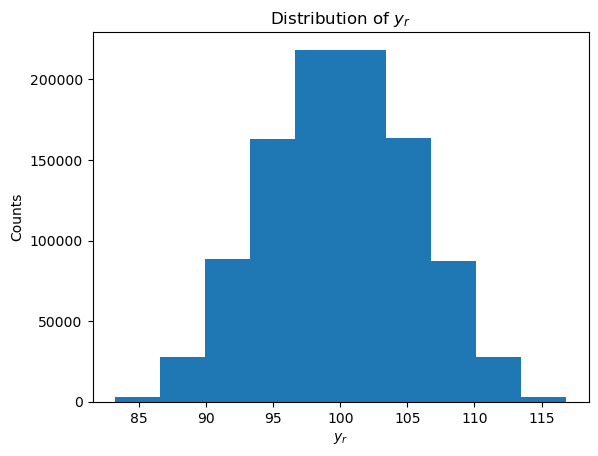

Monte Carlo Method:
y = 100.00062011483149
u(y) = 5.47601079806008

Direct Calculation:
y = 100
u(y) = 5.477225575051661

Testing agreement between each method
Methods agree with 68.27% level of confidence.
Methods agree with 95.45% level of confidence.
Methods agree with 99.73% level of confidence.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()

M = int(1e6)

x1, u_x1 = 10, 1
x2, u_x2 = 20, 2
x3, u_x3 = 30, 3
x4, u_x4 = 40, 4

# Defining functions for the sake of best practices
def random_uniform(x, u_x, M):
    '''Wrapper for the uniform random number generator using more convenient arguments'''
    a = np.sqrt(3) * u_x
    return rng.uniform(low=x - a, high=x + a, size=M)

def f(x1, x2, x3, x4):
    '''Function for calculating y'''
    return x1 + x2 + x3 + x4

def f_uncertainty(u_x1, u_x2, u_x3, u_x4):
    '''Uncertainty propagation formula for f'''
    return np.sqrt(u_x1 * u_x1 +  u_x2 * u_x2 + u_x3 * u_x3 + u_x4 * u_x4)

# Random samples for x_i
x1_r = random_uniform(x1, u_x1, M)
x2_r = random_uniform(x2, u_x2, M)
x3_r = random_uniform(x3, u_x3, M)
x4_r = random_uniform(x4, u_x4, M)

y_r = f(x1_r, x2_r, x3_r, x4_r)

# Inspecting the discrete distribution of y_r
fig, ax = plt.subplots()

ax.hist(y_r)
ax.set_xlabel('$y_r$')
ax.set_ylabel('Counts')
ax.set_title('Distribution of $y_r$')

plt.show()

# Approximating u(y) assuming y_r is distributed normally
y_m = np.mean(y_r)
u_y_m = np.std(y_r, ddof=1)

print('Monte Carlo Method:')
print('y =', y_m)
print('u(y) =', u_y_m)
print()

# Directly calculating y and u(y) using the combined uncertainty formula
y = f(x1, x2, x3, x4)
u_y = f_uncertainty(u_x1, u_x2, u_x3, u_x4)

print('Direct Calculation:')
print('y =', y)
print('u(y) =', u_y)
print()

# Comparing the y/u(y) values we got from each of these methods using different coverage factors (assuming normal distribution)

print('Testing agreement between each method')

d = np.abs(y - y_m)
u_d = np.sqrt(u_y * u_y + u_y_m * u_y_m)

for k, p in zip(
        (1, 2, 3),
        ('68.27%', '95.45%', '99.73%')
    ):
    if d < k * u_d:
        print(f'Methods agree with {p} level of confidence.')
    else:
        print(f'Methods don\'t agree with {p} level of confidence.')

Note that, although the distribution of $y_r$ isn't exactly normal we have treated it as such.
By the central limit theorem, we expect the distribution of $y_r$ to be more normal with an increase in the number of $X_i$ variables ($N$); with the $X_i$ being uniformly distributed, this approach to a normal distribution is slower.

As we can see each of the methods agreed with a confidence level of 68.27% (given this agreement with higher confidence levels are guaranteed).

</div>

## References

```{bibliography}
:cited:
:style: plain
:labelprefix: UMC
:keyprefix: u-mc-
```